# Notebook 1: Data Loading, EDA & Preprocessing
## Framingham Heart Study — 10-Year CVD Risk Prediction

This notebook covers:
1. Loading the Framingham dataset
2. Exploratory Data Analysis (EDA)
3. Feature engineering and preprocessing pipeline
4. Train/test split with SMOTE
5. Saving processed data for model training

In [1]:
import os
import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Load Dataset

In [2]:
df = pd.read_csv('../data/framingham.csv')
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (4240, 16)


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [3]:
df.info()
print("\nMissing values:")
print(df.isnull().sum())
print(f"\nTarget distribution:\n{df['TenYearCHD'].value_counts(normalize=True)}")

<class 'pandas.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   int64  
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-null   float64
 13  heartRate        4239 non-null   float64
 14  glucose          3852 non-null   float64
 15  TenYearCHD       4240 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 530.1 KB

Missing values:
male   

## 2. Feature Renaming & Selection

In [4]:
feature_mapping = {
    'male': 'sex',
    'age': 'age',
    'totChol': 'total_cholesterol',
    'sysBP': 'systolic_bp',
    'diaBP': 'diastolic_bp',
    'BMI': 'bmi',
    'heartRate': 'heart_rate',
    'glucose': 'glucose',
    'currentSmoker': 'smoking',
    'diabetes': 'diabetes',
    'cigsPerDay': 'cigs_per_day',
    'BPMeds': 'bp_meds',
    'prevalentStroke': 'prevalent_stroke',
    'prevalentHyp': 'prevalent_hypertension',
    'education': 'education'
}

df_processed = df.rename(columns=feature_mapping)

df_processed['pulse_pressure'] = df_processed['systolic_bp'] - df_processed['diastolic_bp']

# Selected clinical features for modeling
feature_cols = [
    'age', 'sex', 'total_cholesterol', 'systolic_bp', 'smoking',
    'diabetes', 'bmi', 'heart_rate', 'glucose', 'bp_meds',
    'prevalent_hypertension', 'cigs_per_day', 'pulse_pressure'
]

X = df_processed[feature_cols].copy()
y = df_processed['TenYearCHD'].copy()

print(f"Features ({len(feature_cols)}): {feature_cols}")
print(f"X shape: {X.shape}, y shape: {y.shape}")
X.describe()

Features (13): ['age', 'sex', 'total_cholesterol', 'systolic_bp', 'smoking', 'diabetes', 'bmi', 'heart_rate', 'glucose', 'bp_meds', 'prevalent_hypertension', 'cigs_per_day', 'pulse_pressure']
X shape: (4240, 13), y shape: (4240,)


,age,sex,total_cholesterol,systolic_bp,smoking,diabetes,bmi,heart_rate,glucose,bp_meds,prevalent_hypertension,cigs_per_day,pulse_pressure
count,4240.000000,4240.000000,4190.000000,4240.000000,4240.000000,4240.000000,4221.000000,4239.000000,3852.000000,4187.000000,4240.000000,4211.000000,4240.000000
mean,49.580189,0.429245,236.699523,132.354599,0.494104,0.025708,25.800801,75.878981,81.963655,0.029615,0.310613,9.005937,49.456840
std,8.572942,0.495027,44.591284,22.033300,0.500024,0.158280,4.079840,12.025348,23.954335,0.169544,0.462799,11.922462,14.692384
min,32.000000,0.000000,107.000000,83.500000,0.000000,0.000000,15.540000,44.000000,40.000000,0.000000,0.000000,0.000000,15.000000
25%,42.000000,0.000000,206.000000,117.000000,0.000000,0.000000,23.070000,68.000000,71.000000,0.000000,0.000000,0.000000,40.000000
50%,49.000000,0.000000,234.000000,128.000000,0.000000,0.000000,25.400000,75.000000,78.000000,0.000000,0.000000,0.000000,47.000000
75%,56.000000,1.000000,263.000000,144.000000,1.000000,0.000000,28.040000,83.000000,87.000000,0.000000,1.000000,20.000000,56.000000
max,70.000000,1.000000,696.000000,295.000000,1.000000,1.000000,56.800000,143.000000,394.000000,1.000000,1.000000,70.000000,160.000000


## 3. Exploratory Data Analysis

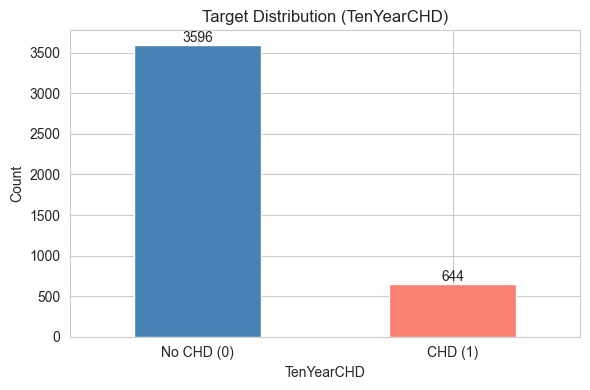

In [5]:
# Target class distribution
fig, ax = plt.subplots(figsize=(6, 4))
y.value_counts().plot(kind='bar', color=['steelblue', 'salmon'], ax=ax)
ax.set_title('Target Distribution (TenYearCHD)')
ax.set_xticklabels(['No CHD (0)', 'CHD (1)'], rotation=0)
ax.set_ylabel('Count')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')
plt.tight_layout()
plt.show()

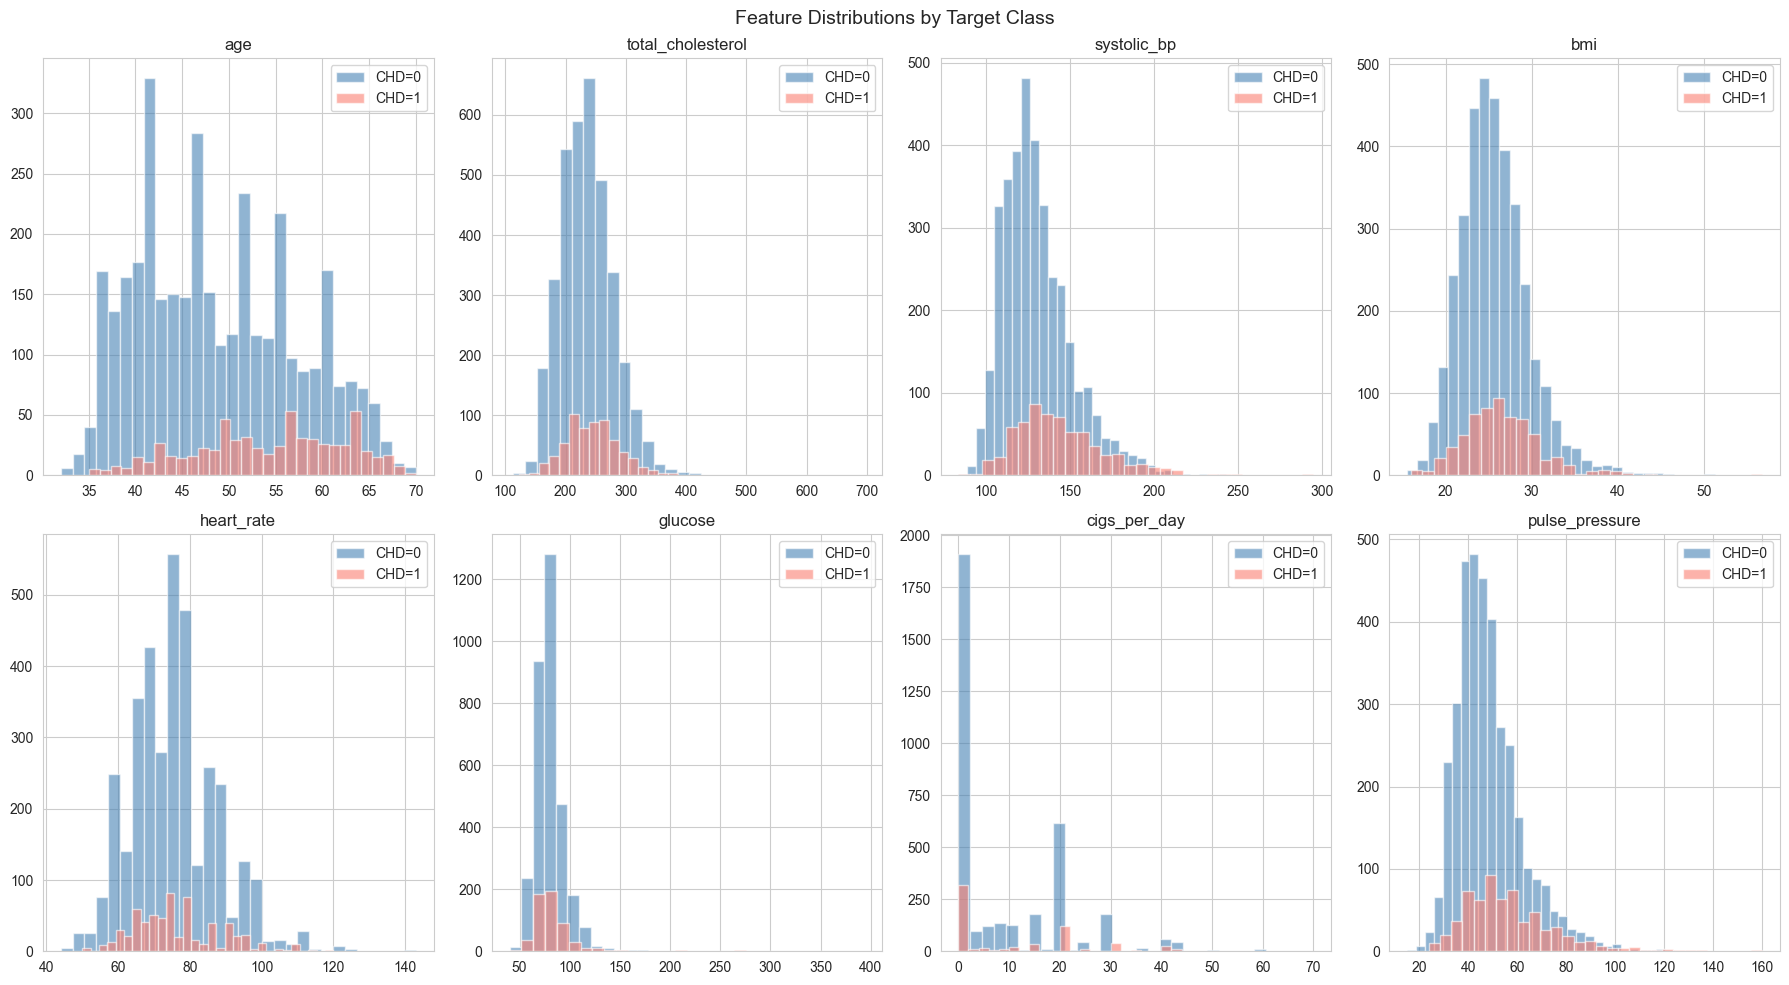

In [6]:
# Feature distributions by target class
continuous_features = ['age', 'total_cholesterol', 'systolic_bp', 'bmi', 'heart_rate', 'glucose',
                       'cigs_per_day', 'pulse_pressure']

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
for i, feat in enumerate(continuous_features):
    ax = axes[i // 4, i % 4]
    for label, color in [(0, 'steelblue'), (1, 'salmon')]:
        subset = X[y == label][feat].dropna()
        ax.hist(subset, bins=30, alpha=0.6, label=f'CHD={label}', color=color)
    ax.set_title(feat)
    ax.legend()

plt.suptitle('Feature Distributions by Target Class', fontsize=14)
plt.tight_layout()
plt.show()

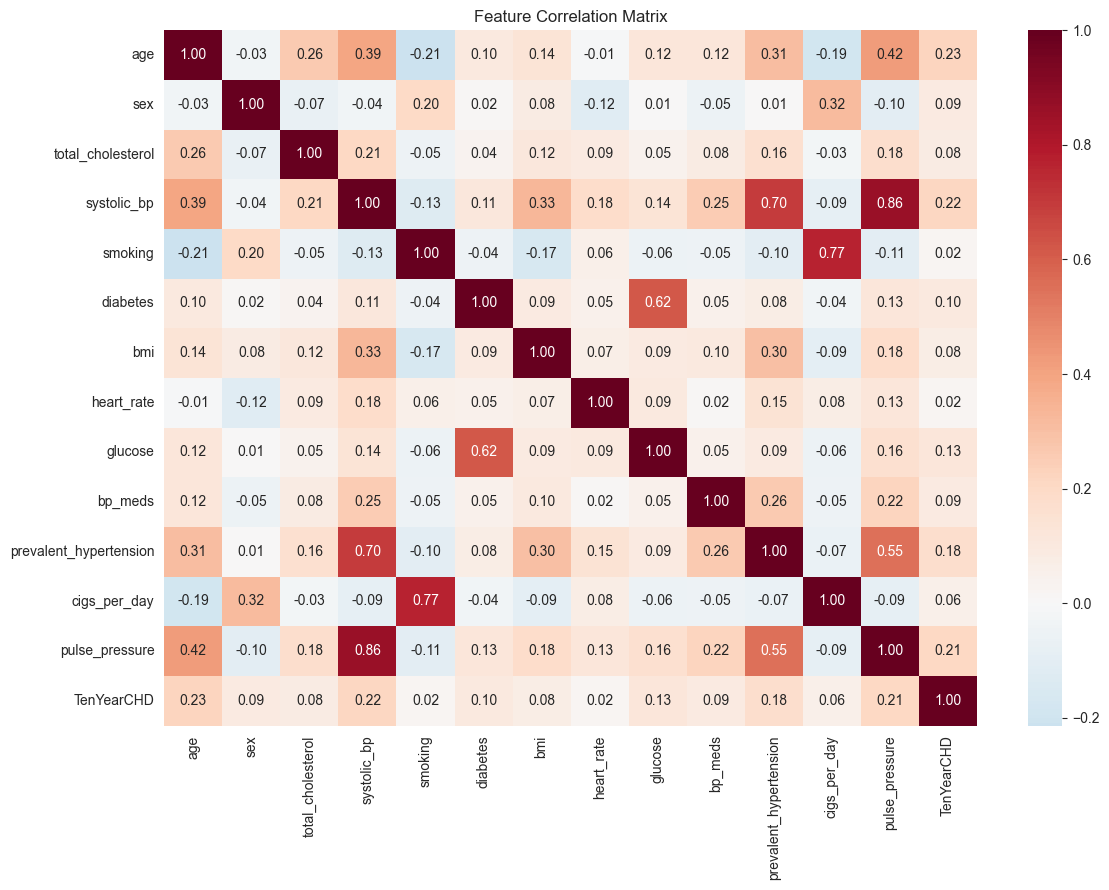

In [7]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(12, 9))
corr_matrix = X.assign(TenYearCHD=y).corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax)
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

## 4. ClinicalPreprocessor & Train/Test Split

In [8]:
class ClinicalPreprocessor:
    """Preprocessing pipeline for clinical data: median imputation + standard scaling."""

    def __init__(self, impute_strategy='median', scale=True):
        self.impute_strategy = impute_strategy
        self.scale = scale
        self.imputer = SimpleImputer(strategy=impute_strategy)
        self.scaler = StandardScaler() if scale else None
        self.feature_names = None

    def fit(self, X, y=None):
        self.feature_names = X.columns.tolist()
        X_imputed = self.imputer.fit_transform(X)
        if self.scaler:
            self.scaler.fit(X_imputed)
        return self

    def transform(self, X):
        X_imputed = self.imputer.transform(X)
        if self.scaler:
            X_scaled = self.scaler.transform(X_imputed)
            return pd.DataFrame(X_scaled, columns=self.feature_names, index=X.index)
        return pd.DataFrame(X_imputed, columns=self.feature_names, index=X.index)

    def fit_transform(self, X, y=None):
        return self.fit(X, y).transform(X)

preprocessor = ClinicalPreprocessor(impute_strategy='median', scale=True)
print("ClinicalPreprocessor initialized")

ClinicalPreprocessor initialized


In [9]:
# Train/test split (80/20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train target distribution:\n{y_train.value_counts(normalize=True)}")
print(f"\nTest target distribution:\n{y_test.value_counts(normalize=True)}")

Train: (3392, 13), Test: (848, 13)
Train target distribution:
TenYearCHD
0    0.848172
1    0.151828
Name: proportion, dtype: float64

Test target distribution:
TenYearCHD
0    0.847877
1    0.152123
Name: proportion, dtype: float64


In [10]:
# Fit preprocessor on training data, transform both sets
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"Missing values after preprocessing (train): {X_train_processed.isnull().sum().sum()}")
print(f"Missing values after preprocessing (test): {X_test_processed.isnull().sum().sum()}")
X_train_processed.describe()

Missing values after preprocessing (train): 0
Missing values after preprocessing (test): 0


,age,sex,total_cholesterol,systolic_bp,smoking,diabetes,bmi,heart_rate,glucose,bp_meds,prevalent_hypertension,cigs_per_day,pulse_pressure
count,3.392000e+03,3.392000e+03,3.392000e+03,3.392000e+03,3.392000e+03,3.392000e+03,3.392000e+03,3.392000e+03,3.392000e+03,3.392000e+03,3.392000e+03,3.392000e+03,3.392000e+03
mean,1.152118e-16,-2.513713e-17,2.555608e-16,6.200491e-16,2.094760e-17,-2.723189e-17,-4.168573e-16,-3.204983e-16,2.304236e-16,2.042391e-17,4.451366e-18,-7.645876e-17,4.189521e-17
std,1.000147e+00,1.000147e+00,1.000147e+00,1.000147e+00,1.000147e+00,1.000147e+00,1.000147e+00,1.000147e+00,1.000147e+00,1.000147e+00,1.000147e+00,1.000147e+00,1.000147e+00
min,-2.060721e+00,-8.661743e-01,-2.950166e+00,-2.221216e+00,-9.842049e-01,-1.632004e-01,-2.499053e+00,-2.656006e+00,-1.811699e+00,-1.706640e-01,-6.709638e-01,-7.517141e-01,-2.355635e+00
25%,-8.940935e-01,-8.661743e-01,-6.977853e-01,-7.007634e-01,-9.842049e-01,-1.632004e-01,-6.644682e-01,-6.572065e-01,-4.176972e-01,-1.706640e-01,-6.709638e-01,-7.517141e-01,-6.514055e-01
50%,-7.745417e-02,-8.661743e-01,-6.074843e-02,-2.015103e-01,-9.842049e-01,-1.632004e-01,-1.080180e-01,-7.422331e-02,-1.563218e-01,-1.706640e-01,-6.709638e-01,-7.517141e-01,-1.742213e-01
75%,7.391851e-01,1.154502e+00,5.762884e-01,5.246761e-01,1.016049e+00,-1.632004e-01,5.383391e-01,5.920432e-01,1.486162e-01,-1.706640e-01,1.490393e+00,9.264025e-01,4.393013e-01
max,2.372464e+00,1.154502e+00,8.266233e+00,7.378060e+00,1.016049e+00,6.127435e+00,7.526771e+00,5.589042e+00,1.360945e+01,5.859465e+00,1.490393e+00,5.121694e+00,7.528896e+00


## 5. SMOTE Oversampling (Training Data Only)

In [11]:
# Apply SMOTE to training data only (oversample minority to 80% of majority)
smote = SMOTE(random_state=RANDOM_STATE, sampling_strategy=0.8)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_processed, y_train)

print(f"Before SMOTE: {y_train.value_counts().to_dict()}")
print(f"After SMOTE:  {pd.Series(y_train_resampled).value_counts().to_dict()}")
print(f"Resampled training set shape: {X_train_resampled.shape}")

Before SMOTE: {0: 2877, 1: 515}
After SMOTE:  {0: 2877, 1: 2301}
Resampled training set shape: (5178, 13)


## 6. Save Artifacts

In [12]:
os.makedirs('../models', exist_ok=True)

# Save preprocessor
with open('../models/preprocessor.pkl', 'wb') as f:
    pickle.dump(preprocessor, f)

# Save processed datasets for Notebook 02
data_artifacts = {
    'X_train_resampled': X_train_resampled,
    'y_train_resampled': y_train_resampled,
    'X_train_processed': X_train_processed,
    'y_train': y_train,
    'X_test_processed': X_test_processed,
    'y_test': y_test,
    'feature_cols': feature_cols,
    'feature_mapping': feature_mapping,
}
with open('../models/processed_data.pkl', 'wb') as f:
    pickle.dump(data_artifacts, f)

print("Saved: models/preprocessor.pkl")
print("Saved: models/processed_data.pkl")
print(f"\nFeature columns ({len(feature_cols)}): {feature_cols}")

Saved: models/preprocessor.pkl
Saved: models/processed_data.pkl

Feature columns (13): ['age', 'sex', 'total_cholesterol', 'systolic_bp', 'smoking', 'diabetes', 'bmi', 'heart_rate', 'glucose', 'bp_meds', 'prevalent_hypertension', 'cigs_per_day', 'pulse_pressure']
